# IMDB Movie Recommender System 🎬

In this project, we build a robust recommendation engine using the MovieLens dataset. We will implement, analyze, and compare three core architectures: **Content-Based Filtering**, **User-Based Collaborative Filtering**, and **Item-Based Collaborative Filtering**.

### 📦 Importing Libraries and Loading Data
We start by importing the necessary data science libraries and loading our raw `movies.csv` and `ratings.csv` datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import joblib

# Loading the datasets
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

print(f'\nMovies Dataset Shape: {movies.shape}')
print(f'Ratings Data Shape: {ratings.shape}\n')
display(movies.head(3))


Movies Dataset Shape: (9742, 3)
Ratings Data Shape: (100836, 4)



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


## 🧹 Data Preprocessing & EDA
To build an effective collaborative filtering model, we need to merge our datasets and resolve any duplicate titles. We will then pivot our data to create a **User-Item Matrix**, which is the foundational structure for Nearest Neighbor algorithms.

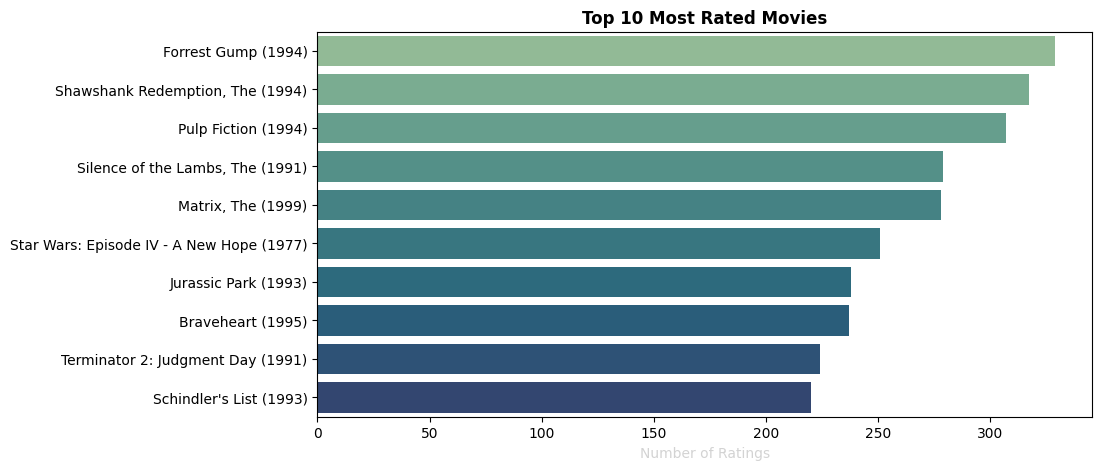


User-Movie Matrix Shape: (610, 9719)



In [2]:
# Merging datasets on movieId
df = pd.merge(ratings, movies, on='movieId')

# Dropping 'timestamp' as it's not needed for basic Collaborative Filtering
df.drop('timestamp', axis=1, inplace=True)

print()

# Visualizing top 10 most rated movies
plt.figure(figsize=(10, 5))
top_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
bars = sns.barplot(x=top_movies.values, y=top_movies.index, hue=top_movies.index, palette='crest', legend=False)

plt.title('Top 10 Most Rated Movies', fontweight='bold')
plt.xlabel('Number of Ratings', color='lightgray')
plt.ylabel('')
plt.show()

# Creating a Pivot Table: Rows = Users, Columns = Movie Titles, Values = Ratings
# Using pivot_table with mean aggregation handles rare duplicate titles gracefully
user_movie_pivot = df.pivot_table(index='userId', columns='title', values='rating').fillna(0)
movie_user_pivot = user_movie_pivot.T

# Converting to Scipy Sparse Matrix for memory efficiency
user_movie_sparse = csr_matrix(user_movie_pivot.values)
movie_user_sparse = csr_matrix(movie_user_pivot.values)

print(f'\nUser-Movie Matrix Shape: {user_movie_pivot.shape}\n')